In [1]:
import numpy as numpy
import pandas as pd

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(DATA_DIR)

f:\Projects\Advanced-Predictive-Maintenance\data\raw


In [3]:
import pandas as pd

errors = pd.read_csv(DATA_DIR / "PdM_errors.csv")
telemetry = pd.read_csv(DATA_DIR / "PdM_telemetry.csv")
machines = pd.read_csv(DATA_DIR / "PdM_machines.csv")
maint = pd.read_csv(DATA_DIR / "PdM_maint.csv")
failures = pd.read_csv(DATA_DIR / "PdM_failures.csv")

🎯 Goal

Compare:

Normal Operation
VS
24 Hours Before Failure

for:

vibration
pressure
volt
rotate

In [4]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])
failures["datetime"] = pd.to_datetime(failures["datetime"])

Step 2: Create Failure Windows

For every failure:

Extract:

24 Hours Before Failure

In [5]:
failure_stats = []

for _, row in failures.iterrows():

    machine_id = row["machineID"]
    failure_time = row["datetime"]

    window = telemetry[
        (telemetry["machineID"] == machine_id)
        &
        (telemetry["datetime"] >= failure_time - pd.Timedelta(hours=24))
        &
        (telemetry["datetime"] < failure_time)
    ]

    if len(window) > 0:

        failure_stats.append({
            "failure_type": row["failure"],

            "mean_vibration":
                window["vibration"].mean(),

            "max_vibration":
                window["vibration"].max(),

            "mean_pressure":
                window["pressure"].mean(),

            "mean_rotate":
                window["rotate"].mean(),

            "mean_volt":
                window["volt"].mean()
        })

In [7]:
failure_stats_df = pd.DataFrame(
    failure_stats
)

failure_stats_df.head()

,failure_type,mean_vibration,max_vibration,mean_pressure,mean_rotate,mean_volt
0,comp4,51.607772,62.464103,98.087115,441.310894,171.333562
1,comp1,39.950596,48.899814,98.781707,441.035876,185.565503
2,comp2,40.007427,50.877634,102.075598,374.896680,170.303958
3,comp4,47.838747,57.504011,101.375959,459.815148,170.255196
4,comp4,57.578478,67.633435,96.558697,443.125092,167.105571


In [8]:
failure_stats_df.describe()

,mean_vibration,max_vibration,mean_pressure,mean_rotate,mean_volt
count,761.000000,761.000000,761.000000,761.000000,761.000000
mean,42.909320,52.761592,105.576237,417.220462,176.169177
std,4.883037,5.596277,10.945261,41.448627,10.309714
min,37.201346,42.412315,92.666905,288.929157,160.318947
25%,39.531361,48.517504,98.994897,374.010506,168.743091
50%,40.463827,50.971346,100.692748,439.806981,171.584917
75%,48.680436,57.368065,103.760672,451.544658,186.702797
max,61.203474,73.948949,150.481279,481.674252,214.375019


Create Normal Windows

Now we need a baseline.

Otherwise we don't know if failure windows are unusual.

Take random normal machine periods.

In [9]:
normal_stats = []

sample_rows = telemetry.sample(
    1000,
    random_state=42
)

In [10]:
for _, row in sample_rows.iterrows():

    machine_id = row["machineID"]
    current_time = row["datetime"]

    window = telemetry[
        (telemetry["machineID"] == machine_id)
        &
        (telemetry["datetime"] >= current_time - pd.Timedelta(hours=24))
        &
        (telemetry["datetime"] < current_time)
    ]

    if len(window) > 0:

        normal_stats.append({
            "mean_vibration":
                window["vibration"].mean(),

            "mean_pressure":
                window["pressure"].mean(),

            "mean_rotate":
                window["rotate"].mean(),

            "mean_volt":
                window["volt"].mean()
        })

In [11]:
normal_stats_df = pd.DataFrame(
    normal_stats
)

Compare Failure vs Normal

In [12]:
print(
    "Failure:",
    failure_stats_df["mean_vibration"].mean()
)

print(
    "Normal:",
    normal_stats_df["mean_vibration"].mean()
)

Failure: 42.90932021509933
Normal: 40.41564696165266


Mean Pressure

In [13]:
print(
    "Failure:",
    failure_stats_df["mean_pressure"].mean()
)

print(
    "Normal:",
    normal_stats_df["mean_pressure"].mean()
)

Failure: 105.57623700966028
Normal: 100.63417611524682


Mean Rotation

In [14]:
print(
    "Failure:",
    failure_stats_df["mean_rotate"].mean()
)

print(
    "Normal:",
    normal_stats_df["mean_rotate"].mean()
)

Failure: 417.22046249060725
Normal: 446.66517613738404


Mean Voltage

In [15]:
print(
    "Failure:",
    failure_stats_df["mean_volt"].mean()
)

print(
    "Normal:",
    normal_stats_df["mean_volt"].mean()
)

Failure: 176.16917711648665
Normal: 170.67898163697544


Visual Comparison
Vibration

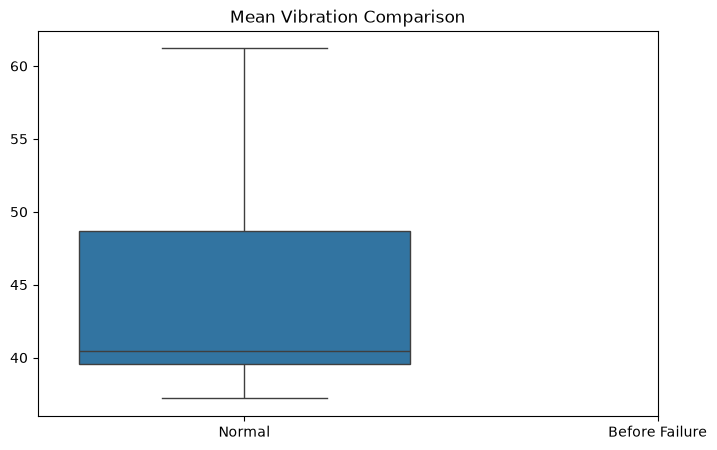

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=[
        normal_stats_df["mean_vibration"],
        failure_stats_df["mean_vibration"]
    ]
)

plt.xticks(
    [0,1],
    ["Normal","Before Failure"]
)

plt.title(
    "Mean Vibration Comparison"
)

plt.show()

In [17]:
failure_stats_df.groupby(
    "failure_type"
)["mean_vibration"].mean()

failure_type
comp1    40.486358
comp2    40.791537
comp3    40.415696
comp4    50.397473
Name: mean_vibration, dtype: float64

In [18]:
failure_stats_df.describe()

normal_stats_df.describe()

,mean_vibration,mean_pressure,mean_rotate,mean_volt
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.415647,100.634176,446.665176,170.678982
std,2.222171,4.276356,17.828386,4.838287
min,35.924487,93.734248,345.928990,154.022949
25%,39.345450,98.822200,441.831818,168.068795
50%,40.125402,100.034681,449.312536,169.977010
75%,40.858375,101.418424,456.180613,172.467952
max,61.581698,147.891017,484.312100,210.353743


In [19]:
failure_stats_df.describe()

,mean_vibration,max_vibration,mean_pressure,mean_rotate,mean_volt
count,761.000000,761.000000,761.000000,761.000000,761.000000
mean,42.909320,52.761592,105.576237,417.220462,176.169177
std,4.883037,5.596277,10.945261,41.448627,10.309714
min,37.201346,42.412315,92.666905,288.929157,160.318947
25%,39.531361,48.517504,98.994897,374.010506,168.743091
50%,40.463827,50.971346,100.692748,439.806981,171.584917
75%,48.680436,57.368065,103.760672,451.544658,186.702797
max,61.203474,73.948949,150.481279,481.674252,214.375019


Major Finding #1
Machines behave differently before failure

This is exactly what we wanted to prove.

If failure and normal windows had identical values:

Failure Vibration = 40.4
Normal Vibration = 40.3

there would be no predictive signal.

But here:

Vibration ↑
Pressure ↑
Voltage ↑
Rotation ↓

before failures.

🚨 Major Finding #2
Rotation is surprisingly important

You found:

Failure Rotation = 417
Normal Rotation = 446

Difference:

-29 RPM

This is a significant shift.

Possible interpretation:

Machines may slow down before failure.

This is a very common industrial pattern.

🚨 Major Finding #3
Comp4 behaves differently

Your output:

comp1 = 40.48
comp2 = 40.79
comp3 = 40.41
comp4 = 50.39

Look at Comp4:

50.39

versus others:

40.xx

That's huge.

Interpretation

Before Comp4 failures:

Vibration increases dramatically

This means:

Vibration is a strong predictor for Comp4 failures.

🎯 EDA Conclusion

report:

Key Findings
Failure windows exhibit measurable deviations from normal operation.
Vibration increases before failures.
Pressure and voltage are elevated before failures.
Rotation decreases before failures.
Comp4 failures show significantly higher vibration than other failure types.
Sensor telemetry contains predictive signals suitable for anomaly detection.

Not only vibration.

For all sensors:

In [20]:
failure_stats_df.groupby("failure_type").mean()

,mean_vibration,max_vibration,mean_pressure,mean_rotate,mean_volt
failure_type,,,,,
comp1,40.486358,50.496283,101.563204,442.651905,190.957571
comp2,40.791537,50.666795,101.554417,368.665766,171.256939
comp3,40.415696,49.853533,125.485912,443.222611,171.386512
comp4,50.397473,60.350684,101.129233,441.167658,170.914580


In [21]:
failure_stats_df.groupby(
    "failure_type"
)[
    [
        "mean_vibration",
        "mean_pressure",
        "mean_rotate",
        "mean_volt"
    ]
].mean()

,mean_vibration,mean_pressure,mean_rotate,mean_volt
failure_type,,,,
comp1,40.486358,101.563204,442.651905,190.957571
comp2,40.791537,101.554417,368.665766,171.256939
comp3,40.415696,125.485912,443.222611,171.386512
comp4,50.397473,101.129233,441.167658,170.914580
